In [1]:
from pathlib import Path
import gc

import anndata as ad
from scipy.sparse import csr_matrix, issparse

ad.settings.allow_write_nullable_strings = True

DATA_DIR = Path('/Users/chrislangseth/Downloads/autism-data')
OUTPUT_DIR = Path('/Volumes/processing2/autism')
PROCESSED_DIR = OUTPUT_DIR / 'processed_sparse_filtered'
CONCAT_PATH = OUTPUT_DIR / 'autism_concatenated_filtered_sparse.h5ad'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/Volumes/processing2/autism')

In [2]:
h5ad_paths = sorted(p for p in DATA_DIR.glob('*.h5ad') if not p.name.startswith('._'))

if not h5ad_paths:
    raise FileNotFoundError(f'No .h5ad files found in {DATA_DIR}')

print(f'Found {len(h5ad_paths)} files:')
for path in h5ad_paths:
    print(f'  - {path.name}')

h5ad_paths

Found 13 files:
  - Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob7-BRA-5-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob8-BRA-4-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob8-BRA-5_temporal__GEX_NMF_anatomical_region_cell_type.h5ad
  - Hob8-BRA-6-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad
  - Sob20-BRA-0-FFPE-4-S25__GEX_NMF_anatomical_region_cell_type.h5ad
  - Sob23-BRA-0-FFPE-4__GEX_NMF_anatomical_region_cell_type.h5ad
  - Sob23-BRA-0-FFPE-5__GEX_NMF_anatomical_region_cell_type.h5ad
  - Sob23-BRA-0-FFPE-6__GEX_NMF_anatomical_region_cell_type.h5ad
  - Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type.h5ad


[PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob7-BRA-5-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob8-BRA-4-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob8-BRA-5_temporal__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Downloads/autism-data/Hob8-BRA-6-FFPE-1__GEX_NMF_anatomical_region_cell_type.h5ad'),
 PosixPath('/Users/chrislangseth/Download

In [ ]:
processed_paths = []

for path in h5ad_paths:
    print(f'Processing {path.name}')
    adata_one = ad.read_h5ad(path)

    if 'tangram_cell_type' not in adata_one.obs.columns:
        raise KeyError(f"tangram_cell_type not found in obs for {path.name}")

    adata_one = adata_one[adata_one.obs.tangram_cell_type.notna()].copy()

    if not issparse(adata_one.X):
        adata_one.X = csr_matrix(adata_one.X)
    else:
        adata_one.X = adata_one.X.tocsr()

    out_path = PROCESSED_DIR / f'{path.stem}__filtered_sparse.h5ad'
    adata_one.write_h5ad(out_path, convert_strings_to_categoricals=False)
    processed_paths.append(out_path)

    print(f'  wrote: {out_path}')
    print(f'  kept cells: {adata_one.n_obs:,}')
    print(f'  genes: {adata_one.n_vars:,}')

    del adata_one
    gc.collect()

processed_paths

Processing Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type.h5ad
  wrote: /Volumes/processing2/autism/processed_sparse_filtered/Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  kept cells: 511,234
  genes: 315
Processing Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type.h5ad
  wrote: /Volumes/processing2/autism/processed_sparse_filtered/Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  kept cells: 470,870
  genes: 315
Processing Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type.h5ad
  wrote: /Volumes/processing2/autism/processed_sparse_filtered/Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  kept cells: 531,706
  genes: 315
Processing Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type.h5ad
  wrote: /Volumes/processing2/autism/processed_sparse_filtered/Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  kept cells: 671,594
  g

[PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob7-BRA-5-FFPE-1__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob8-BRA-4-FFPE-1__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad'),
 PosixPath('/Volumes/processing2/autism/processed_sparse_filtered/Hob8-BRA-5_temporal__GEX_NMF_anatomical_regio

In [15]:
from collections import defaultdict

paths_by_nvars = defaultdict(list)

for path in processed_paths:
    adata_meta = ad.read_h5ad(path, backed='r')
    paths_by_nvars[adata_meta.n_vars].append(path)
    if hasattr(adata_meta, 'file') and adata_meta.file is not None:
        adata_meta.file.close()

for n_vars, paths in sorted(paths_by_nvars.items()):
    print(f'Gene count {n_vars}: {len(paths)} files')
    for path in paths:
        print(f'  - {path.name}')

def concat_group(group_paths, out_path):
    keys = [path.stem.replace('__filtered_sparse', '') for path in group_paths]

    try:
        from anndata.experimental import concat_on_disk

        concat_on_disk(
            [str(path) for path in group_paths],
            out_file=str(out_path),
            axis=0,
            join='inner',
            merge='same',
            label='source_file',
            keys=keys,
            index_unique='__',
        )
        print(f'Built grouped H5AD on disk: {out_path}')
    except Exception as e:
        print(f'concat_on_disk unavailable ({type(e).__name__}: {e}); falling back to in-memory concat for {out_path.name}')
        adatas = [ad.read_h5ad(path) for path in group_paths]
        adata_group = ad.concat(
            adatas,
            axis=0,
            join='inner',
            merge='same',
            label='source_file',
            keys=keys,
            index_unique='__',
        )
        if not issparse(adata_group.X):
            adata_group.X = csr_matrix(adata_group.X)
        else:
            adata_group.X = adata_group.X.tocsr()
        adata_group.write_h5ad(out_path, convert_strings_to_categoricals=False)
        del adata_group, adatas
        gc.collect()
        print(f'Built grouped H5AD with fallback concat: {out_path}')

split_concat_paths = {}
for n_vars, group_paths in sorted(paths_by_nvars.items()):
    out_path = OUTPUT_DIR / f'autism_concatenated_filtered_sparse_{n_vars}genes.h5ad'
    concat_group(group_paths, out_path)
    split_concat_paths[n_vars] = out_path

split_concat_paths

Gene count 315: 7 files
  - Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob23-BRA-6_occipital__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob5-BRA-5-FFPE-1-S142__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob7-BRA-3_frontal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob8-BRA-5_temporal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Sob20-BRA-0-FFPE-4-S25__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
Gene count 485: 6 files
  - Hob7-BRA-5-FFPE-1__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob8-BRA-4-FFPE-1__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Hob8-BRA-6-FFPE-1__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Sob23-BRA-0-FFPE-4__GEX_NMF_anatomical_region_cell_type__filtered_sparse.h5ad
  - Sob23-BRA-0-FFPE-5__GEX_NMF_a

{315: PosixPath('/Volumes/processing2/autism/autism_concatenated_filtered_sparse_315genes.h5ad'),
 485: PosixPath('/Volumes/processing2/autism/autism_concatenated_filtered_sparse_485genes.h5ad')}

In [11]:
keys = [path.stem.replace('__filtered_sparse', '') for path in processed_paths]

try:
    from anndata.experimental import concat_on_disk

    concat_on_disk(
        [str(path) for path in processed_paths],
        out_file=str(CONCAT_PATH),
        axis=0,
        join='inner',
        merge='same',
        label='source_file',
        keys=keys,
        index_unique='__',
    )
    print(f'Built concatenated H5AD on disk: {CONCAT_PATH}')
except Exception as e:
    print(f'concat_on_disk unavailable ({type(e).__name__}: {e}); falling back to in-memory concat')
    adatas = [ad.read_h5ad(path) for path in processed_paths]
    adata = ad.concat(
        adatas,
        axis=0,
        join='inner',
        merge='same',
        label='source_file',
        keys=keys,
        index_unique='__',
    )
    if not issparse(adata.X):
        adata.X = csr_matrix(adata.X)
    else:
        adata.X = adata.X.tocsr()
    adata.write_h5ad(CONCAT_PATH, convert_strings_to_categoricals=False)
    del adata, adatas
    gc.collect()
    print(f'Built concatenated H5AD with fallback concat: {CONCAT_PATH}')

print(f'Final concatenated file: {CONCAT_PATH}')
CONCAT_PATH

Built concatenated H5AD on disk: /Volumes/processing2/autism/autism_concatenated_filtered_sparse.h5ad
Final concatenated file: /Volumes/processing2/autism/autism_concatenated_filtered_sparse.h5ad


PosixPath('/Volumes/processing2/autism/autism_concatenated_filtered_sparse.h5ad')

In [12]:
# Optional: load the final concatenated H5AD into memory.
adata = ad.read_h5ad(CONCAT_PATH)
print(f'Concatenated object: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
adata

Concatenated object: 7,181,827 cells x 315 genes


AnnData object with n_obs × n_vars = 7181827 × 315
    obs: 'n_genes_by_counts', 'total_counts', 'slide', 'anatomical_region', 'tangram_cell_type', 'tangram_cell_type_Cortex', 'tangram_scrna_reference', 'source_file'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'

In [13]:
adata.obs

,n_genes_by_counts,total_counts,slide,anatomical_region,tangram_cell_type,tangram_cell_type_Cortex,tangram_scrna_reference,source_file
cell_563__Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type,81,145.0,Hob23-BRA-4_parietal,CP_parietal cortex,InCGE,InCGE,Polioudakis2019,Hob23-BRA-4_parietal__GEX_NMF_anatomical_regio...
cell_613__Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type,95,160.0,Hob23-BRA-4_parietal,CP_parietal cortex,InCGE,InCGE,Polioudakis2019,Hob23-BRA-4_parietal__GEX_NMF_anatomical_regio...
cell_622__Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type,83,146.0,Hob23-BRA-4_parietal,CP_parietal cortex,ExM,ExM,Polioudakis2019,Hob23-BRA-4_parietal__GEX_NMF_anatomical_regio...
cell_630__Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type,86,159.0,Hob23-BRA-4_parietal,CP_parietal cortex,Mic,Mic,Polioudakis2019,Hob23-BRA-4_parietal__GEX_NMF_anatomical_regio...
cell_634__Hob23-BRA-4_parietal__GEX_NMF_anatomical_region_cell_type,123,311.0,Hob23-BRA-4_parietal,CP_parietal cortex,ExM,ExM,Polioudakis2019,Hob23-BRA-4_parietal__GEX_NMF_anatomical_regio...
...,...,...,...,...,...,...,...,...
cell_1335358__Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type,114,245.0,Sob23-BRA_frontotemporal,CP_frontal cortex,ExM,ExM,Polioudakis2019,Sob23-BRA_frontotemporal__GEX_NMF_anatomical_r...
cell_1335369__Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type,65,91.0,Sob23-BRA_frontotemporal,CP_frontal cortex,Per,Per,Polioudakis2019,Sob23-BRA_frontotemporal__GEX_NMF_anatomical_r...
cell_1335378__Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type,105,235.0,Sob23-BRA_frontotemporal,CP_frontal cortex,Mic,Mic,Polioudakis2019,Sob23-BRA_frontotemporal__GEX_NMF_anatomical_r...
cell_1335397__Sob23-BRA_frontotemporal__GEX_NMF_anatomical_region_cell_type,23,28.0,Sob23-BRA_frontotemporal,CP_frontal cortex,PgG2M,PgG2M,Polioudakis2019,Sob23-BRA_frontotemporal__GEX_NMF_anatomical_r...


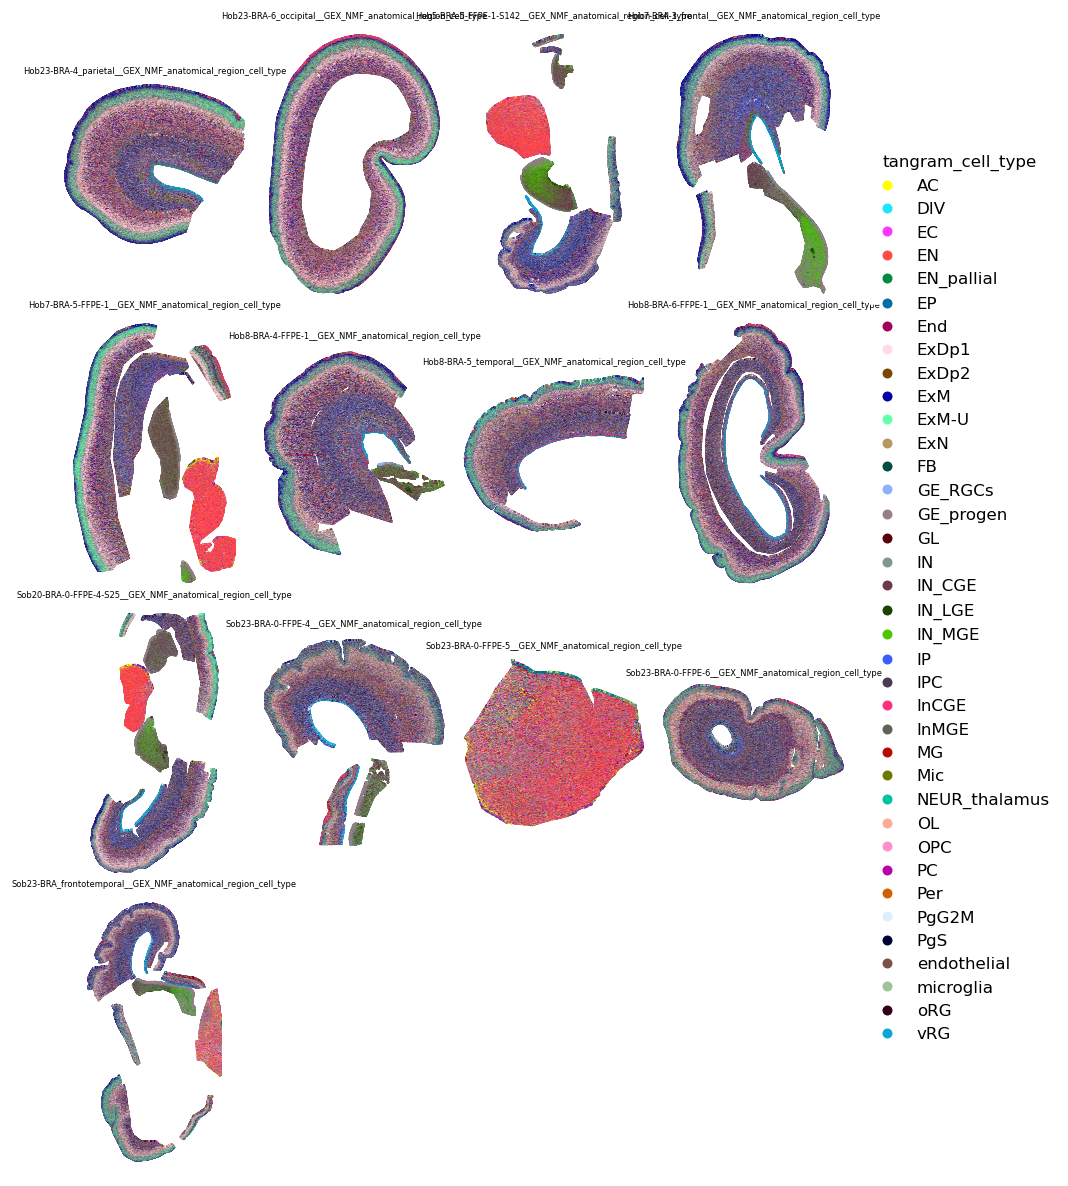

In [10]:
import sys
sys.path.append("/Users/chrislangseth/work/karolinska_institutet/projects/BaloMS/")
from utils import spatial_utils

spatial_utils.plot_spatial_compact_fast(
    adata,
    color="tangram_cell_type",
    groupby="source_file",
    spot_size=1,
    cols=4,
    height=10,
    background="white",
    dpi=120,
)
